In [2]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


Total number of classes: 27

Top 5 most represented styles:
 - Impressionism: 13060 images
 - Realism: 10733 images
 - Romanticism: 7019 images
 - Expressionism: 6736 images
 - Post_Impressionism: 6450 images

5 least represented styles:
 - Contemporary_Realism: 481 images
 - New_Realism: 314 images
 - Synthetic_Cubism: 216 images
 - Analytical_Cubism: 110 images
 - Action_painting: 98 images


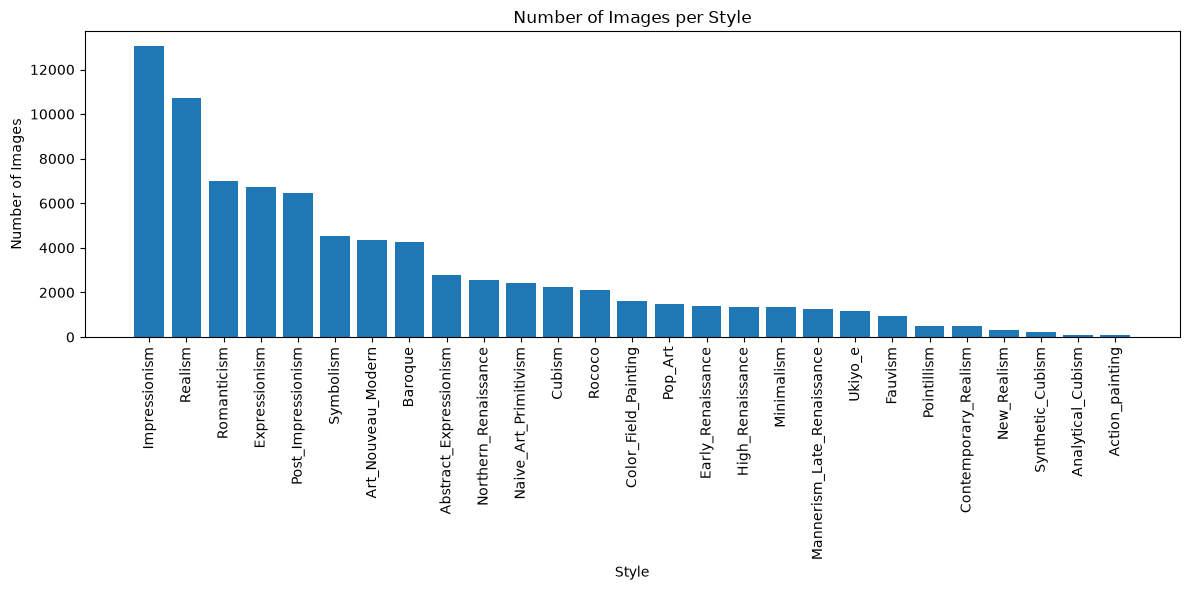

In [7]:
# File paths and class counts
data_dir = "WikiArt/wikiart/versions/1/"
classes = sorted(os.listdir(data_dir))
print(f"Total number of classes: {len(classes)}\n")

class_counts = {}
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

# Sort and display the class counts
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
print("Top 5 most represented styles:")
for name, count in sorted_counts[:5]:
    print(f" - {name}: {count} images")

print("\n5 least represented styles:")
for name, count in sorted_counts[-5:]:
    print(f" - {name}: {count} images")



# display plot with all styles and their counts ascending order
plt.figure(figsize=(12, 6))
plt.bar([x[0] for x in sorted_counts], [x[1] for x in sorted_counts])
plt.xticks(rotation=90)
plt.title("Number of Images per Style")
plt.xlabel("Style")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [8]:
# Define transformations for the images (resize, convert to tensor, normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Standard size for many CNNs
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet standard
])

# Load the dataset using ImageFolder, which expects a directory structure where each class has its own folder
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Create a DataLoader to handle batching and shuffling of the dataset
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

print(f"Number of samples in the dataset: {len(dataset)}")
print(f"Mapping of classes to indices: {dataset.class_to_idx}")

Number of samples in the dataset: 81444
Mapping of classes to indices: {'Abstract_Expressionism': 0, 'Action_painting': 1, 'Analytical_Cubism': 2, 'Art_Nouveau_Modern': 3, 'Baroque': 4, 'Color_Field_Painting': 5, 'Contemporary_Realism': 6, 'Cubism': 7, 'Early_Renaissance': 8, 'Expressionism': 9, 'Fauvism': 10, 'High_Renaissance': 11, 'Impressionism': 12, 'Mannerism_Late_Renaissance': 13, 'Minimalism': 14, 'Naive_Art_Primitivism': 15, 'New_Realism': 16, 'Northern_Renaissance': 17, 'Pointillism': 18, 'Pop_Art': 19, 'Post_Impressionism': 20, 'Realism': 21, 'Rococo': 22, 'Romanticism': 23, 'Symbolism': 24, 'Synthetic_Cubism': 25, 'Ukiyo_e': 26}


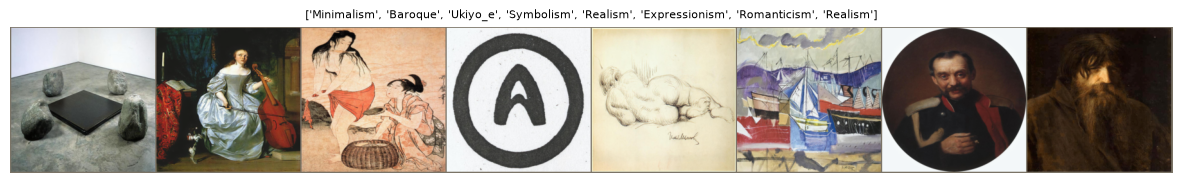

In [9]:
import numpy as np

# function to display images in a grid
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=8)
    plt.axis('off')

# Get a batch of training data
inputs, classes_idx = next(iter(dataloader))
class_names = dataset.classes

# Display the first 8 images from the batch
plt.figure(figsize=(15, 6))
out = torchvision.utils.make_grid(inputs[:8])
imshow(out, title=[class_names[x] for x in classes_idx[:8]])
plt.show()